In [2]:
# Suppress warnings and set up the environment
import os
import sys
import warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

# Quick context manager to hide the libjpeg C-level errors during feature extraction
class HideOutputs:
    def __enter__(self):
        self.null_fd = os.open(os.devnull, os.O_WRONLY)
        self.save_fd = os.dup(2)
        os.dup2(self.null_fd, 2)

    def __exit__(self, *_):
        os.dup2(self.save_fd, 2)
        os.close(self.null_fd)
        os.close(self.save_fd)

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

print(f"TF Version: {tf.__version__}")
print(f"GPUs Available: {len(tf.config.list_physical_devices('GPU'))}")

TF Version: 2.19.0
GPUs Available: 1


In [3]:
# # Download and extract the datasets
# !echo "Fetching annotations..."
# !wget -qO- "https://zenodo.org/records/6390798/files/embryo_dataset_annotations.tar.gz" | tar -xz -C /kaggle/working/

# !echo "Fetching image frames (this takes a bit)..."
# !wget -qO- "https://zenodo.org/records/6390798/files/embryo_dataset.tar.gz" | tar -xz -C /kaggle/working/

# print("Data ready!")

In [4]:
# Import all required libraries
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, TimeDistributed, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
BASE_DATA_PATH = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset/embryo_dataset' 
BASE_CSV_PATH = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset_annotations/embryo_dataset_annotations'
SAVED_FEATURES_FILE = '/kaggle/working/cached_mobilenet_features.npz' # Keep this in /working/ to allow saving

IMAGE_DIMS = (224, 224)
CNN_FEATURES = 1280
TIMESTEPS = 6
SLIDING_WINDOW = 15
BATCH = 64
TOTAL_EPOCHS = 50

# Developmental stages mapping
STAGES = ['pPB2', 'pPNa', 'pPNf', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8', 'p9+', 'pM', 'pSB', 'pB', 'pEB', 'pHB']
STAGE_MAP = {stage: index for index, stage in enumerate(STAGES)}
TOTAL_CLASSES = len(STAGES)

In [6]:
# Gather files
all_csvs = glob.glob(f"{BASE_CSV_PATH}/**/*.csv", recursive=True)
video_folders = [f for f in os.listdir(BASE_DATA_PATH) if os.path.isdir(os.path.join(BASE_DATA_PATH, f))]

print(f"Total Videos Found: {len(video_folders)}")
print(f"Total CSVs Found: {len(all_csvs)}")

# Inspect a single CSV
demo_csv = all_csvs[0]
demo_df = pd.read_csv(demo_csv, header=None, names=['stage', 'start_frame', 'end_frame'])
print(f"\nAnnotations for {os.path.basename(demo_csv)}:")
display(demo_df.head())

Total Videos Found: 704
Total CSVs Found: 704

Annotations for BC750-7_phases.csv:


,stage,start_frame,end_frame
0,tPB2,6,17
1,tPNa,18,76
2,tPNf,77,84
3,t2,85,139
4,t4,140,195


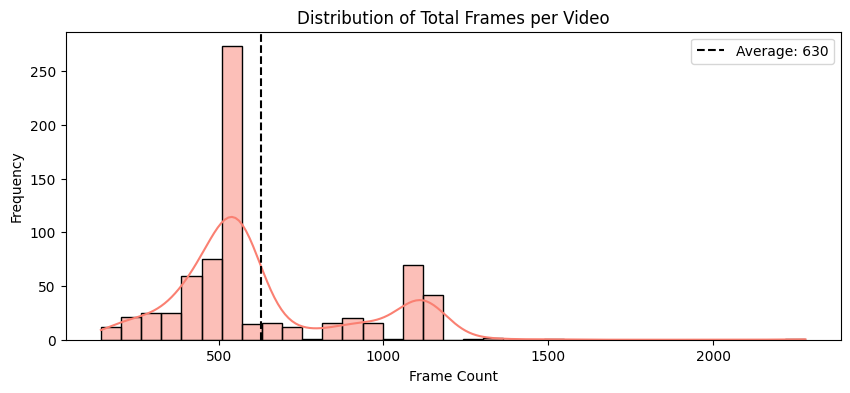

In [7]:
# Analyze video lengths
frames_per_vid = []
for csv in all_csvs:
    vid_id = os.path.basename(csv).replace('_phases.csv', '')
    folder_path = os.path.join(BASE_DATA_PATH, vid_id)
    if os.path.exists(folder_path):
        img_count = len(glob.glob(f"{folder_path}/**/*.jp*g", recursive=True))
        if img_count > 0:
            frames_per_vid.append(img_count)

plt.figure(figsize=(10, 4))
sns.histplot(frames_per_vid, bins=35, kde=True, color='salmon')
plt.axvline(np.mean(frames_per_vid), color='black', linestyle='dashed', label=f'Average: {np.mean(frames_per_vid):.0f}')
plt.title("Distribution of Total Frames per Video")
plt.xlabel("Frame Count")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [8]:
# Build the CNN base for feature extraction
mobilenet_base = MobileNetV2(input_shape=(IMAGE_DIMS[0], IMAGE_DIMS[1], 3), include_top=False, weights='imagenet')

# Attach global average pooling
cnn_extractor = Sequential([
    mobilenet_base,
    GlobalAveragePooling2D()
])
cnn_extractor.trainable = False

print("CNN Extractor Architecture:")
cnn_extractor.summary()

I0000 00:00:1776937192.372561      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
CNN Extractor Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
# Run feature extraction on the entire dataset and save to disk
if os.path.exists(SAVED_FEATURES_FILE):
    print("Loading pre-extracted features from disk...")
    archive = np.load(SAVED_FEATURES_FILE, allow_pickle=True)
    extracted_data = archive['extracted_data'].item()
    print(f"Successfully loaded features for {len(extracted_data)} embryos.")
else:
    print("Extracting features (This will take a while)...")
    extracted_data = {} 

    with HideOutputs(): # Suppresses libjpeg errors
        for idx, csv_path in enumerate(all_csvs):
            vid_name = os.path.basename(csv_path).replace('_phases.csv', '')
            vid_dir = os.path.join(BASE_DATA_PATH, vid_name)
            
            if not os.path.exists(vid_dir): 
                continue

            # Create a dictionary of frame numbers to their class indices
            df = pd.read_csv(csv_path, header=None, names=['stage', 'start', 'end'])
            labels_dict = {}
            for _, row in df.iterrows():
                stage_val = str(row['stage']).strip()
                cleaned_stage = ('p' + stage_val[1:]) if stage_val.startswith('t') else stage_val
                
                if cleaned_stage in STAGE_MAP:
                    for f_num in range(int(row['start']), int(row['end']) + 1):
                        labels_dict[f_num] = STAGE_MAP[cleaned_stage]

            # Get all images and sort them chronologically
            image_paths = glob.glob(os.path.join(vid_dir, '**', '*.jp*g'), recursive=True)
            valid_frames = []
            
            for path in image_paths:
                match = re.search(r'(\d+)\.jp', path)
                if match:
                    frame_idx = int(match.group(1))
                    if frame_idx in labels_dict:
                        valid_frames.append((frame_idx, path, labels_dict[frame_idx]))
                        
            valid_frames.sort(key=lambda x: x[0])

            if len(valid_frames) < TIMESTEPS:
                continue

            vid_feats, vid_labels = [], []
            CHUNK_SIZE = 32
            
            # Process in chunks
            for i in range(0, len(valid_frames), CHUNK_SIZE):
                chunk = valid_frames[i : i + CHUNK_SIZE]
                loaded_imgs = []
                
                for _, pth, lbl in chunk:
                    try:
                        raw = tf.io.read_file(pth)
                        decoded = tf.image.decode_jpeg(raw, channels=1)
                        rgb = tf.image.grayscale_to_rgb(decoded)
                        resized = tf.image.resize(rgb, IMAGE_DIMS)
                        final_img = preprocess_input(resized)
                        loaded_imgs.append(final_img)
                        vid_labels.append(lbl)
                    except:
                        pass 
                        
                if loaded_imgs:
                    tensor_batch = tf.stack(loaded_imgs)
                    features = cnn_extractor.predict(tensor_batch, verbose=0)
                    vid_feats.append(features)

            if vid_feats:
                extracted_data[vid_name] = {
                    'x': np.vstack(vid_feats),
                    'y': np.array(vid_labels)
                }

            if (idx + 1) % 50 == 0:
                print(f"Processed {idx + 1} / {len(all_csvs)} videos")

    np.savez_compressed(SAVED_FEATURES_FILE, extracted_data=extracted_data)
    print("Feature extraction complete and saved to disk.")

Extracting features (This will take a while)...
Processed 50 / 704 videos
Processed 100 / 704 videos
Processed 150 / 704 videos
Processed 200 / 704 videos
Processed 250 / 704 videos
Processed 300 / 704 videos
Processed 350 / 704 videos
Processed 400 / 704 videos
Processed 450 / 704 videos
Processed 500 / 704 videos
Processed 550 / 704 videos
Processed 600 / 704 videos
Processed 650 / 704 videos
Processed 700 / 704 videos
Feature extraction complete and saved to disk.


In [10]:
# Convert continuous video features into chunked sequences for the LSTM
def build_lstm_sequences(data_dict, time_steps, step_size):
    sequences, targets, p_ids = [], [], []

    for vid_id, contents in data_dict.items():
        x_data = contents['x']
        y_data = contents['y']
        patient = vid_id.split('-')[0]
        
        total_len = len(x_data)
        
        # Standard for-loop instead of while loop
        for i in range(0, total_len - time_steps + 1, step_size):
            sequences.append(x_data[i : i + time_steps])
            targets.append(y_data[i : i + time_steps])
            p_ids.append(patient)

    return np.array(sequences), np.array(targets), np.array(p_ids)

seq_x, seq_y, seq_patients = build_lstm_sequences(extracted_data, TIMESTEPS, SLIDING_WINDOW)

print(f"Generated {len(seq_x)} sequences.")
print(f"Data Shape: {seq_x.shape}")
print(f"Label Shape: {seq_y.shape}")

Generated 23380 sequences.
Data Shape: (23380, 6, 1280)
Label Shape: (23380, 6)


In [11]:
# Split data ensuring no patient overlap between sets
splitter = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=101)
train_idx, other_idx = next(splitter.split(seq_x, groups=seq_patients))

train_x, train_y = seq_x[train_idx], seq_y[train_idx]
other_x, other_y = seq_x[other_idx], seq_y[other_idx]
other_patients   = seq_patients[other_idx]

splitter_2 = GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=101)
val_idx, test_idx = next(splitter_2.split(other_x, groups=other_patients))

val_x, val_y = other_x[val_idx], other_y[val_idx]
test_x, test_y = other_x[test_idx], other_y[test_idx]

print(f"Training sequences: {len(train_x)}")
print(f"Validation sequences: {len(val_x)}")
print(f"Testing sequences: {len(test_x)}")

Training sequences: 16652
Validation sequences: 3163
Testing sequences: 3565


In [12]:
# Custom Loss Function to penalize predicting the wrong sequence order
def sequence_ordinal_loss(penalty_weight=0.5):
    idx_tensor = tf.cast(tf.range(TOTAL_CLASSES), tf.float32)

    def compute_loss(actual_y, predicted_y):
        # Base classification loss
        base_cce = tf.keras.losses.sparse_categorical_crossentropy(actual_y, predicted_y)
        
        # Calculate the "distance" of the mistake
        actual_float = tf.cast(actual_y, tf.float32)
        expected_pred = tf.reduce_sum(predicted_y * idx_tensor, axis=-1)
        distance_penalty = tf.square(actual_float - expected_pred)
        
        # Combine and average across the time dimension
        total_loss = base_cce + (penalty_weight * distance_penalty)
        return tf.reduce_mean(total_loss, axis=-1)
        
    return compute_loss

In [13]:
# Construct the LSTM Model using Sequential API
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(TIMESTEPS, CNN_FEATURES)),
    Dropout(0.35),
    TimeDistributed(Dense(TOTAL_CLASSES, activation='softmax'))
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=sequence_ordinal_loss(0.5),
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 6, 64)          │       344,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 6, 16)          │         1,040 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 345,360 (1.32 MB)

 Trainable params: 345,360 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train the model
training_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)
]

print("Starting LSTM Training Process...")
history_log = lstm_model.fit(
    train_x, train_y,
    validation_data=(val_x, val_y),
    epochs=TOTAL_EPOCHS,
    batch_size=BATCH,
    callbacks=training_callbacks
)

Starting LSTM Training Process...
Epoch 1/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.2951 - loss: 4.8438 - val_accuracy: 0.4919 - val_loss: 3.2662 - learning_rate: 0.0010
Epoch 2/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5140 - loss: 2.4559 - val_accuracy: 0.5230 - val_loss: 3.0608 - learning_rate: 0.0010
Epoch 3/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5516 - loss: 2.1679 - val_accuracy: 0.5386 - val_loss: 2.8819 - learning_rate: 0.0010
Epoch 4/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5792 - loss: 1.9337 - val_accuracy: 0.5496 - val_loss: 2.8612 - learning_rate: 0.0010
Epoch 5/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5982 - loss: 1.7864 - val_accuracy: 0.5562 - val_loss: 2.9630 - learning_rate: 0.0010
Epoch 6/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6182 - loss: 1.6685 - val_accuracy: 0.5556 - val_loss: 2.8369 - learning_rate: 0.0010
Epoch 7/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step -

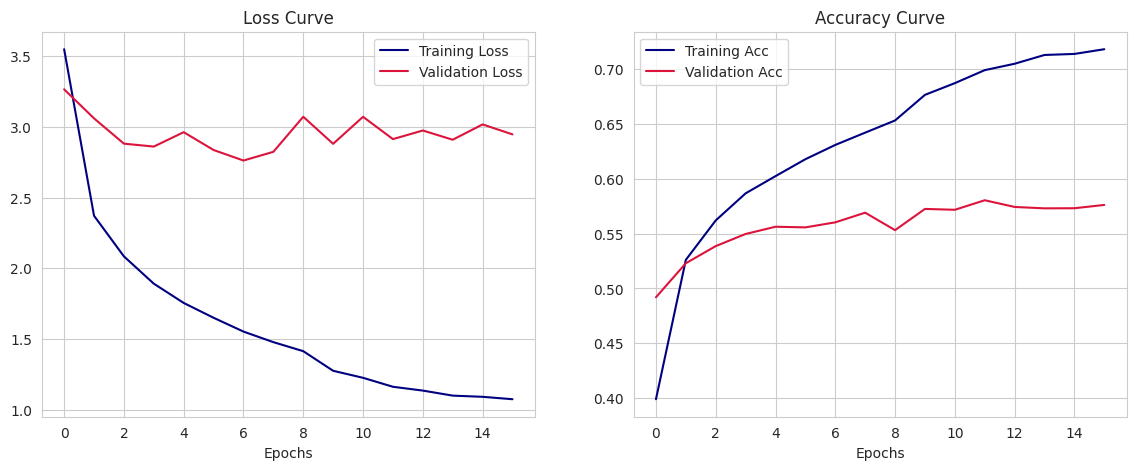

In [15]:
# Plot Training Results
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_log.history['loss'], label='Training Loss', color='navy')
axes[0].plot(history_log.history['val_loss'], label='Validation Loss', color='crimson')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epochs')
axes[0].legend()

axes[1].plot(history_log.history['accuracy'], label='Training Acc', color='navy')
axes[1].plot(history_log.history['val_accuracy'], label='Validation Acc', color='crimson')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epochs')
axes[1].legend()

plt.show()

In [17]:
# Evaluate on the hold-out test set
raw_predictions = lstm_model.predict(test_x)

# Flatten sequences down to individual frames to calculate metrics
flat_preds = np.argmax(raw_predictions.reshape(-1, TOTAL_CLASSES), axis=-1)
flat_actuals = test_y.flatten()

accuracy_score = np.mean(flat_preds == flat_actuals)
print(f"\nFinal Frame-Level Test Accuracy: {accuracy_score * 100:.2f}%")

print("\nDetailed Classification Report:")
# print(classification_report(flat_actuals, flat_preds, target_names=STAGES, zero_division=0))
print(classification_report(flat_actuals, flat_preds, labels=range(TOTAL_CLASSES), target_names=STAGES, zero_division=0))

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Final Frame-Level Test Accuracy: 58.73%

Detailed Classification Report:
              precision    recall  f1-score   support

        pPB2       0.53      0.49      0.51       891
        pPNa       0.73      0.89      0.80      3026
        pPNf       0.44      0.15      0.23       510
          p2       0.64      0.74      0.68      2195
          p3       0.00      0.00      0.00       317
          p4       0.55      0.66      0.60      2167
          p5       0.25      0.00      0.01       478
          p6       0.21      0.04      0.07       596
          p7       0.03      0.00      0.01       798
          p8       0.49      0.57      0.53      2358
         p9+       0.57      0.73      0.64      3645
          pM       0.51      0.42      0.46      1286
         pSB       0.55      0.39      0.46      1197
          pB       0.45      0.20      0.27       624
         pEB       0.63      0.88      0.74      1302
         pHB       0

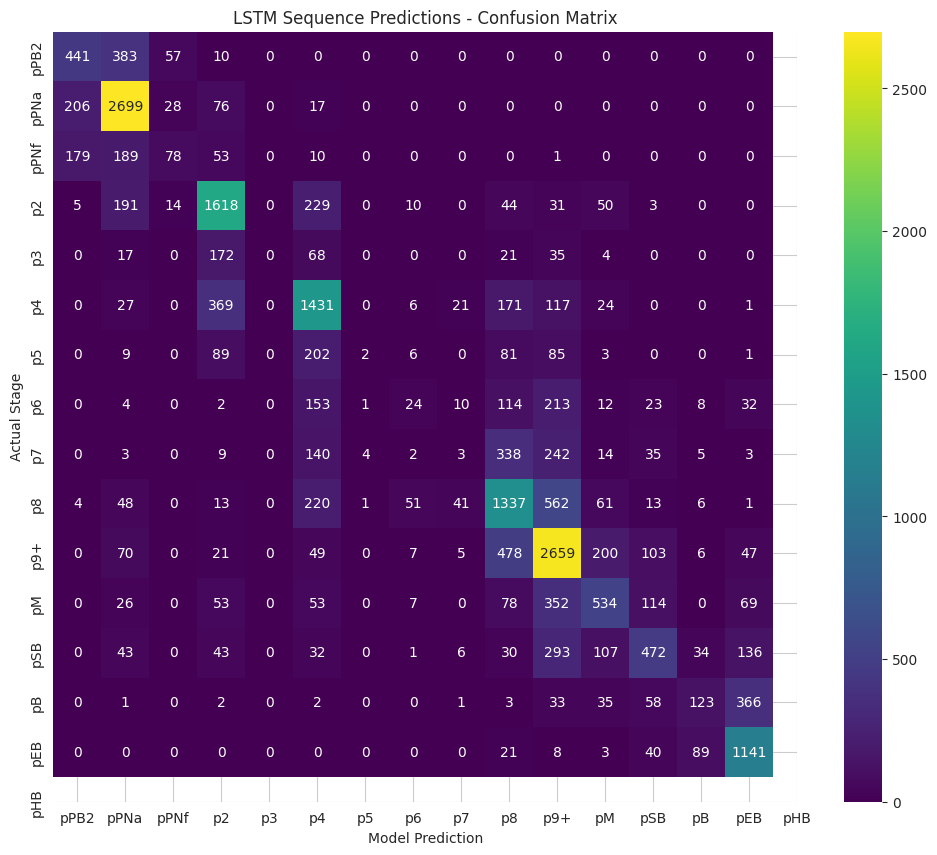

In [18]:
# Display Confusion Matrix
conf_mat = confusion_matrix(flat_actuals, flat_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='viridis', 
            xticklabels=STAGES, yticklabels=STAGES)
plt.title("LSTM Sequence Predictions - Confusion Matrix")
plt.xlabel("Model Prediction")
plt.ylabel("Actual Stage")
plt.show()

In [19]:
# Calculate Ordinal Mistakes
absolute_errors = np.abs(flat_actuals - flat_preds)

print("--- Ordinal Distance Analysis ---")
print(f"Average Stage Error: {absolute_errors.mean():.3f} stages off")
print(f"Perfect Matches: {(absolute_errors == 0).mean()*100:.2f}%")
print(f"Off by 1 Stage max: {(absolute_errors <= 1).mean()*100:.2f}%")
print(f"Off by 2 Stages max: {(absolute_errors <= 2).mean()*100:.2f}%")

--- Ordinal Distance Analysis ---
Average Stage Error: 0.944 stages off
Perfect Matches: 58.73%
Off by 1 Stage max: 77.77%
Off by 2 Stages max: 89.09%
